In [1]:
## imports
import os
import gdown
import zipfile

## Download Dataset

FILE_ID  = '1Rj0EYgDy0sy7jc7-KXvQiHwpqA0Dzj__'
ZIP_PATH = '/content/drowsiness_dataset.zip'
DATA_DIR = '/content/dataset'

if not os.path.exists(ZIP_PATH):
    print("Downloading...")
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
else:
    print("Already downloaded")

Downloading...


Downloading...
From (original): https://drive.google.com/uc?id=1Rj0EYgDy0sy7jc7-KXvQiHwpqA0Dzj__
From (redirected): https://drive.google.com/uc?id=1Rj0EYgDy0sy7jc7-KXvQiHwpqA0Dzj__&confirm=t&uuid=ebc5cd23-5dc1-4aaf-8f6f-48c0118e7c60
To: /content/drowsiness_dataset.zip
100%|██████████| 169M/169M [00:02<00:00, 68.2MB/s]


In [2]:
## Extract Dataset
if not os.path.exists(DATA_DIR):
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Done")
else:
    print("Already extracted")

Extracting...
Done


In [3]:
import os
# Check Dataset Content
print(os.listdir(DATA_DIR))

['train']


In [4]:
import os
## Find Class Structure

CLASSES = ['Closed', 'Open', 'no_yawn', 'yawn']

raw_root = None

for root, dirs, files in os.walk(DATA_DIR):
    if all(c in dirs for c in CLASSES):
        raw_root = root
        break

print("Dataset root:", raw_root)

Dataset root: /content/dataset/train


In [ ]:
# 🔍 Dataset Class Distribution (EDA)
for cls in CLASSES:
    print(cls, len(os.listdir(os.path.join(raw_root, cls))))

In [5]:
import shutil, random
## Create Train/Val/Test Split

SPLIT_DIR = "/content/split_data"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

SPLITS = {'train': 0.7, 'val': 0.15, 'test': 0.15}

for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls))

for cls in CLASSES:
    src = os.path.join(raw_root, cls)
    imgs = os.listdir(src)
    random.shuffle(imgs)

    n = len(imgs)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    split_map = {
        'train': imgs[:n_train],
        'val': imgs[n_train:n_train+n_val],
        'test': imgs[n_train+n_val:]
    }

    for split, files in split_map.items():
        for f in files:
            shutil.copy(os.path.join(src, f),
                        os.path.join(SPLIT_DIR, split, cls))

print("Split done")

Split done


In [6]:
import os

print(os.listdir("/content/split_data"))
print(os.listdir("/content/split_data/train"))

['val', 'test', 'train']
['no_yawn', 'Closed', 'Open', 'yawn']


In [7]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_dir = "/content/split_data/train"
val_dir   = "/content/split_data/val"
test_dir  = "/content/split_data/test"

## Load datasets
train_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
val_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
test_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_raw.class_names
print("Classes:", class_names)
# Expected: ['Closed', 'Open', 'no_yawn', 'yawn']

## Normalization layer (scales pixels from 0-255 → 0-1)
normalization = layers.Rescaling(1./255)

## Augmentation pipeline (applied only to training data)
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="augmentation")

## Apply augmentation + normalization to train, only normalization to val/test
def preprocess_train(images, labels):
    images = augmentation(images, training=True)
    images = normalization(images)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds   = val_raw.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_raw.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print(" Datasets ready")
print(f"   Train batches : {len(train_ds)}")
print(f"   Val batches   : {len(val_ds)}")
print(f"   Test batches  : {len(test_ds)}")

Found 2029 files belonging to 4 classes.
Found 432 files belonging to 4 classes.
Found 439 files belonging to 4 classes.
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']
 Datasets ready
   Train batches : 64
   Val batches   : 14
   Test batches  : 14


In [8]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),


    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),


    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),


    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor  = 'val_accuracy' ,
        patience = 5,
        restore_best_weights =  True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   =  0.5,
        patience = 3,
        verbose  = 1,
    )
]
cnn_history=cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20    ,
    callbacks=callbacks
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 443s 7s/step - accuracy: 0.5086 - loss: 0.8804 - val_accuracy: 0.2500 - val_loss: 3.7808 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 409s 6s/step - accuracy: 0.5525 - loss: 0.7447 - val_accuracy: 0.2523 - val_loss: 5.0340 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 417s 7s/step - accuracy: 0.5973 - loss: 0.7036 - val_accuracy: 0.2500 - val_loss: 6.6057 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6204 - loss: 0.6766
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 403s 6s/step - accuracy: 0.6456 - loss: 0.6517 - val_accuracy: 0.2500 - val_loss: 6.4156 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 417s 7s/step - accuracy: 0.6856 - loss: 0.5933 - val_accuracy: 0.2500 - val_loss: 5.6263 - learning_rate: 5.0000e-04
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 411s 6s/step - accuracy: 0.7072 - loss: 0.5422 - val_ac

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,369,550 (5.22 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 912,394 (3.48 MB)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights = "imagenet",
    include_top = False,
    input_shape = (224,224,3)
)

In [ ]:
base_model.trainable = False

In [ ]:
from tensorflow.keras import layers, models
mobilenet_model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(4, activation='softmax')
])

In [ ]:
mobilenet_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [ ]:
history = mobilenet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = callbacks
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6274 - loss: 0.8153 - val_accuracy: 0.8148 - val_loss: 0.4069 - learning_rate: 1.0000e-04
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8053 - loss: 0.4026 - val_accuracy: 0.8333 - val_loss: 0.3581 - learning_rate: 1.0000e-04
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8270 - loss: 0.3386 - val_accuracy: 0.8333 - val_loss: 0.3393 - learning_rate: 1.0000e-04
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8487 - loss: 0.3036 - val_accuracy: 0.8426 - val_loss: 0.3311 - learning_rate: 1.0000e-04
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8635 - loss: 0.2864 - val_accuracy: 0.8264 - val_loss: 0.3381 - learning_rate: 1.0000e-04
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8669 - loss: 0.2714 - val_accuracy: 0.8333 - val_loss: 0.3282 - learning_rate: 1.0000e-04
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8842 -

In [ ]:
base_model.trainable = True

In [ ]:
mobilenet_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [ ]:
mobilenet_history = mobilenet_model.fit (
    train_ds,
    validation_data = val_ds,
    epochs = 5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 456s 7s/step - accuracy: 0.7758 - loss: 0.5309 - val_accuracy: 0.8449 - val_loss: 0.3111
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 433s 7s/step - accuracy: 0.8659 - loss: 0.3284 - val_accuracy: 0.8611 - val_loss: 0.2817
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 422s 7s/step - accuracy: 0.9172 - loss: 0.2299 - val_accuracy: 0.8681 - val_loss: 0.2685
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 420s 7s/step - accuracy: 0.9359 - loss: 0.1888 - val_accuracy: 0.8935 - val_loss: 0.2536
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 419s 7s/step - accuracy: 0.9650 - loss: 0.1298 - val_accuracy: 0.8912 - val_loss: 0.2436


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/drowsiness_models"
os.makedirs(SAVE_DIR, exist_ok=True)

cnn_model.save(f"{SAVE_DIR}/cnn_model.h5")
mobilenet_model.save(f"{SAVE_DIR}/mobilenet_model.h5")
print("✅ Models saved to Drive!")

In [2]:
import matplotlib.pyplot as plt

# Extract metrics
loss = mobilenet_history.history['loss']
val_loss = mobilenet_history.history['val_loss']

accuracy = mobilenet_history.history['accuracy']
val_accuracy = mobilenet_history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

# 🔹 LOSS GRAPH
plt.figure()
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()

# 🔹 ACCURACY GRAPH
plt.figure()
plt.plot(epochs, accuracy)
plt.plot(epochs, val_accuracy)
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Acc", "Val Acc"])
plt.show()

NameError: name 'mobilenet_history' is not defined

In [ ]:
# Add after MobileNet plots
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [3]:
cnn_model.save('cnn_model.h5')
mobilenet_model.save('mobilenet_model.h5')

NameError: name 'cnn_model' is not defined

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_ds)
mob_loss, mob_acc = mobilenet_model.evaluate(test_ds)

print("CNN Test Accuracy:", cnn_acc)
print("MobileNet Test Accuracy:", mob_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.2506 - loss: 3.6662
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8588 - loss: 0.2847
CNN Test Accuracy: 0.2505694627761841
MobileNet Test Accuracy: 0.858769953250885


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Step 1 — collect true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = mobilenet_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


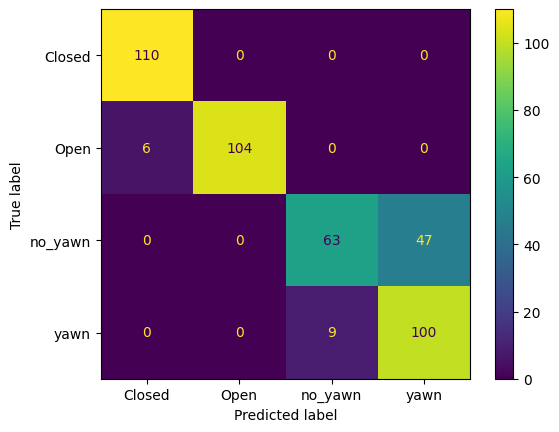

In [ ]:
## Step 2 — plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = class_names
)
disp.plot()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names = class_names
))

              precision    recall  f1-score   support

      Closed       0.95      1.00      0.97       110
        Open       1.00      0.95      0.97       110
     no_yawn       0.88      0.57      0.69       110
        yawn       0.68      0.92      0.78       109

    accuracy                           0.86       439
   macro avg       0.88      0.86      0.85       439
weighted avg       0.88      0.86      0.85       439



In [ ]:
fatigue_levels = []

for pred in y_pred:
    label = class_names[pred]

    if label == 'Closed':
        fatigue_levels.append(2)

    elif label == 'yawn':
        fatigue_levels.append(1)

    else:  # Open or no_yawn
        fatigue_levels.append(0)

In [ ]:
from collections import Counter

# Fatigue progression over time intervals
fatigue_progression = []
interval_size = 20  # frames per time block

for start_index in range(0, len(fatigue_levels), interval_size):
    end_index = start_index + interval_size
    time_interval_data = fatigue_levels[start_index:end_index]

    fatigue_counts = Counter(time_interval_data)
    dominant_fatigue_level = max(fatigue_counts, key=fatigue_counts.get)

    fatigue_progression.append(dominant_fatigue_level)

print("Fatigue level per time interval:", fatigue_progression)

In [ ]:
import matplotlib.pyplot as plt

# Plot the fatigue progression curve
plt.figure(figsize=(12, 5))

# Plot with markers
plt.plot(fatigue_progression, marker='o', linewidth=2, markersize=8, color='red')

# Customize the plot
plt.xlabel('Time Interval', fontsize=12)
plt.ylabel('Fatigue Level', fontsize=12)
plt.title('Driver Fatigue Progression Over Time', fontsize=14)

# Set Y-axis ticks (0,1,2) with labels
plt.yticks([0, 1, 2], ['🟢 Alert (0)', '🟡 Mild Fatigue (1)', '🔴 Severe Fatigue (2)'])

# Add grid for readability
plt.grid(True, alpha=0.3, linestyle='--')

# Mark transition points (where fatigue increases)
for i in range(1, len(fatigue_progression)):
    if fatigue_progression[i] > fatigue_progression[i-1]:
        plt.axvline(x=i, color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
        plt.text(i, fatigue_progression[i] + 0.1, '⚠️', ha='center', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("FATIGUE TRANSITION ANALYSIS")
print("="*50)

for i in range(1, len(fatigue_progression)):
    if fatigue_progression[i] > fatigue_progression[i-1]:
        if fatigue_progression[i-1] == 0 and fatigue_progression[i] == 1:
            print(f"⚠️ Interval {i}: Driver went from ALERT → MILD FATIGUE")
        elif fatigue_progression[i-1] == 1 and fatigue_progression[i] == 2:
            print(f"⚠️ Interval {i}: Driver went from MILD FATIGUE → SEVERE FATIGUE")
        elif fatigue_progression[i-1] == 0 and fatigue_progression[i] == 2:
            print(f"⚠️ Interval {i}: Driver went from ALERT → SEVERE FATIGUE (sudden)")

if len(fatigue_progression) > 0:
    print(f"\nFinal fatigue state: ", end="")
    if fatigue_progression[-1] == 0:
        print("🟢 ALERT")
    elif fatigue_progression[-1] == 1:
        print("🟡 MILD FATIGUE")
    else:
        print("🔴 SEVERE FATIGUE")